In [21]:
import mne
from mne.datasets import sample
import matplotlib.pyplot as plt
# 让图片显示在单元格内，而不是弹窗
%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [7]:
#
data_path = "../data/sample_audvis_filt-0-40_raw.fif"
raw = mne.io.read_raw_fif(data_path)

Opening raw data file ../data/sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.


In [4]:
# 376 x 41700 表示 376 个通道，41700 个采样点，277.7 s 是有效记录时长
print(raw)

<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~3.3 MiB, data not loaded>


In [5]:
print(raw.info)

<Info | 15 non-empty values
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 40.0 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off, Average EEG reference: off
 sfreq: 150.2 Hz
>


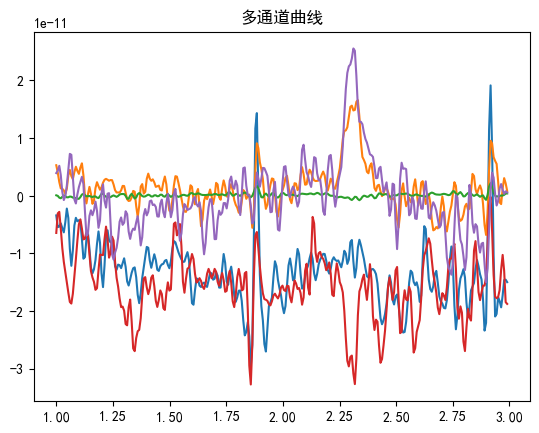

In [10]:
# 从 Raw 对象的 info 字典中读取采样频率（单位：Hz，即每秒采样点数）
sfreq = raw.info['sfreq']
# 提取数据：选取前 5 个通道（索引 0~4），时间范围从第 1 秒到第 3 秒
# int(sfreq*1) 和 int(sfreq*3) 将物理时间转换为对应的采样点索引
# data 形状为 (5, n_times)，times 为对应的时间轴（单位：秒）
data, times = raw[:5, int(sfreq*1):int(sfreq*3)]
# data.T 将维度转置为 (n_times, n_channels)
# 这样 matplotlib 会把每个通道画成一条独立的曲线，横轴为时间，纵轴为信号幅值
plt.plot(times, data.T)
plt.title('多通道曲线')
plt.show()

Effective window size : 13.639 (s)
Plotting power spectral density (dB=True).


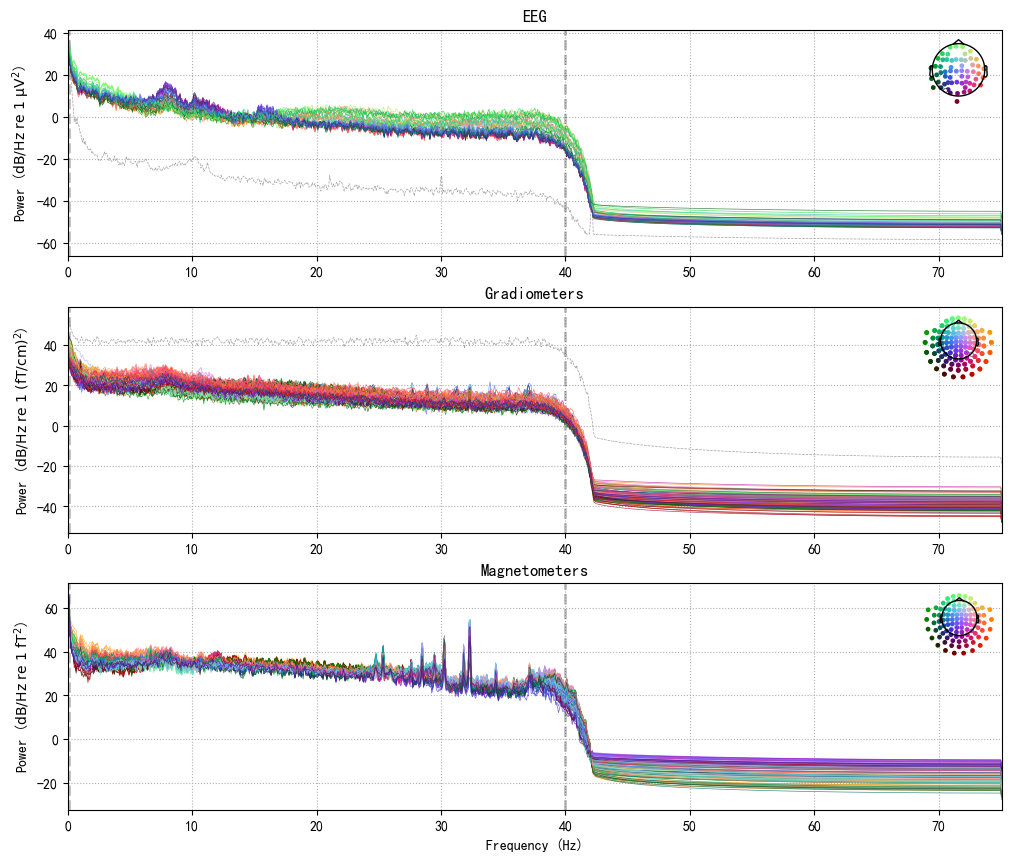

In [11]:
# 去除警告信息
import warnings
warnings.filterwarnings('ignore', message='FigureCanvasAgg is non-interactive')

# 绘制原始信号各通道的功率谱密度（Power Spectral Density, PSD），
# 该函数对每个通道的时序信号做频谱分析，展示不同频率上的能量分布，
# 常用于：检查工频干扰（如 50/60Hz 处是否有尖峰）、观察频带特征（如 10Hz 附近的 α 波）、评估滤波效果或识别噪声较大的通道
# 默认使用 Welch 方法计算 PSD
raw.compute_psd().plot()
plt.show()

# 关于三张图右上角的小标：
# EEG 电极是贴在头皮表面的，所以 EEG 那张图右上角的小图标看起来很“规整”
# Grad/MEG 传感器不是贴在头皮上的，而是固定在一个头盔形（helmet）低温杜瓦容器里，
# 把这些三维坐标投影成二维俯视图时，位于头盔下缘（靠近脖子方向）的传感器在投影上会被“挤”到头圆外部很远的位置

Effective window size : 13.639 (s)


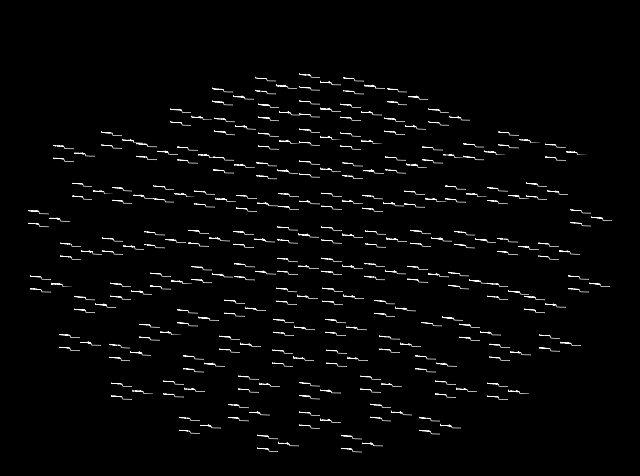

In [12]:
# 绘制各通道功率谱密度（PSD）的地形分布图（Topographic Map）
# 该函数先计算每个通道在不同频段的 PSD，然后将这些功率值映射到头皮/头盔的二维拓扑视图上，
# 以颜色深浅表示各区域能量强弱，常用于直观观察大脑节律活动的空间分布，
# 例如判断 α 波（8-12 Hz）是否在枕叶区域功率最强、β 波是否集中在中央运动区等
raw.compute_psd().plot_topo()
plt.show()

mag 共 102 个通道，前 10 个名字： ['MEG 0111', 'MEG 0121', 'MEG 0131', 'MEG 0141', 'MEG 0211', 'MEG 0221', 'MEG 0231', 'MEG 0241', 'MEG 0311', 'MEG 0321']
选中： ['MEG 0111', 'MEG 0121', 'MEG 0131', 'MEG 0141', 'MEG 0211', 'MEG 0221', 'MEG 0231', 'MEG 0241']
Effective window size : 13.639 (s)


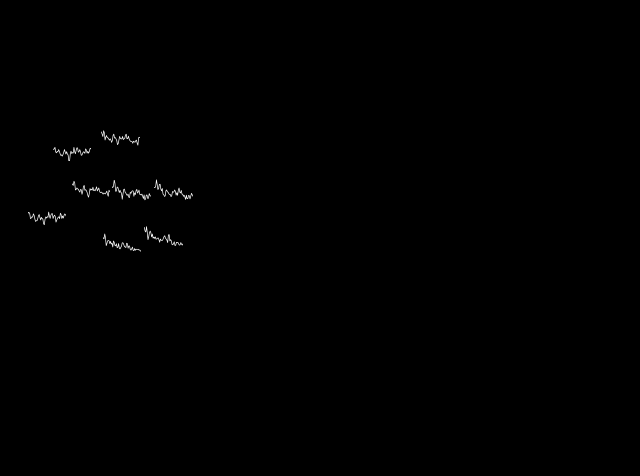

In [16]:
# 绘制 左听觉区附近的 8 个磁强计、8–12 Hz alpha 频段 的地形分布图（Topographic Map）
# ========= 参数区（想看哪里就改这里）=========
CH_TYPE   = 'mag'                      # 'mag' / 'grad' / 'eeg' 三选一
FMIN, FMAX = 8, 12                     # 频段范围：这里看 alpha
START, STOP = 0, 8                     # 取该类型通道中的第 0~7 个（共 8 个）
# ============================================

# 挑出通道类型
raw_pick = raw.copy().pick(CH_TYPE)
# 按名字挑出局部通道
all_names = raw_pick.ch_names
print(f'{CH_TYPE} 共 {len(all_names)} 个通道，前 10 个名字：', all_names[:10])
# 按索引挑局部
sel_names = all_names[START:STOP]
print('选中：', sel_names)
raw_local = raw_pick.pick(sel_names)
# 绘图
psd = raw_local.compute_psd(fmin=FMIN, fmax=FMAX)
fig = psd.plot_topo()
fig.suptitle(f'{CH_TYPE.upper()}  {FMIN}-{FMAX} Hz  ({len(sel_names)} ch)')
plt.show()

In [15]:
# 创建raw对象，构建raw对象需要准备两种数据，一种是data，另一种是info

In [22]:
import mne
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [23]:
# 生成一段随机的模拟脑电/脑磁数据，形状为 (n_channels, n_times)，5 个通道，每个通道 1000 个采样点，数据服从标准正态分布
data = np.random.randn(5, 1000)

# 手动创建 MNE 的 Info 对象，描述这段数据的元信息
info = mne.create_info(
    ch_names=['MEG1', 'MEG2', 'EEG1', 'EEG2', 'MOG'],
    # 每个通道的类型：grad=MEG 梯度计，eeg=脑电电极，eog=眼电
    ch_types=['grad', 'grad', 'eeg', 'eeg', 'eog'],
    # 采样频率：100 Hz，即每秒采集 100 个点
    sfreq=100,
)

# 用数据和 Info 对象构造一个 MNE Raw 对象，RawArray 用于将内存中的 NumPy 数组包装成 MNE 标准的 Raw 格式
custom_raw = mne.io.RawArray(data, info)

Creating RawArray with float64 data, n_channels=5, n_times=1000
    Range : 0 ... 999 =      0.000 ...     9.990 secs
Ready.


In [24]:
print(custom_raw)

<RawArray | 5 x 1000 (10.0 s), ~49 KiB, data loaded>


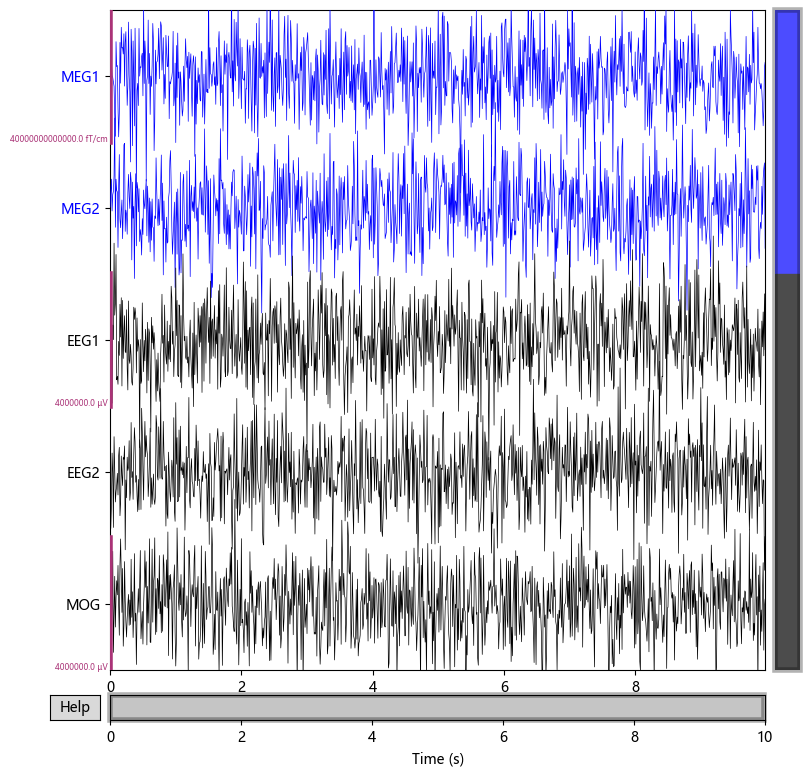

In [25]:
# 定义各通道类型的显示缩放比例（单位：数据单位 / 绘图单位）。
# 该值用于在波形图中统一不同通道类型的显示幅度，使它们在纵轴上看起来大小相近，便于同时观察。
# 数值越大，该类型通道在图中的波形显示得越"矮"。
scalings = {'eeg': 2, 'grad': 2, 'eog': 2}

# 绘制 Raw 对象的连续波形图
custom_raw.plot(n_channels=5, scalings=scalings)
plt.show()

In [ ]:
# 使用正余弦数据模拟信号

In [26]:
sfreq = 1000
times = np.arange(0, 10, 0.001)
sin = np.sin(times * 10)
cos = np.cos(times * 10)
sin_2x = sin * 2
cos_2x = cos * 2

data = np.array([sin, cos, sin_2x, cos_2x])

info = mne.create_info(
    ch_names=['sin', 'cos', 'sin_2x', 'cos_2x'],
    ch_types=['mag', 'mag', 'grad', 'grad'],
    sfreq=sfreq,
)

custom_sin_raw = mne.io.RawArray(data, info)

Creating RawArray with float64 data, n_channels=4, n_times=10000
    Range : 0 ... 9999 =      0.000 ...     9.999 secs
Ready.


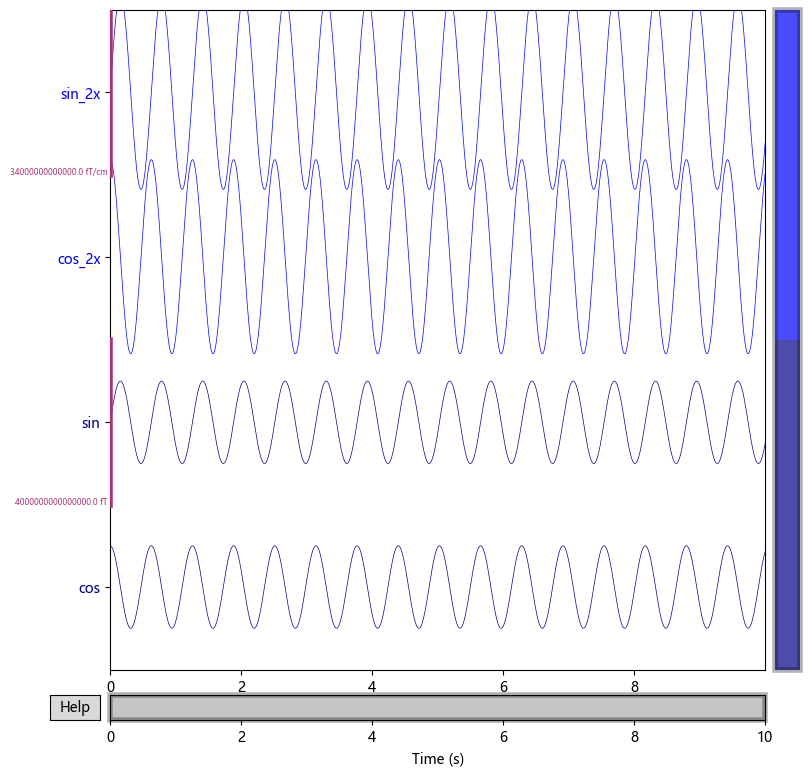

In [27]:
scalings = {'mag': 2, 'grad': 1.7}

# 绘制 Raw 对象的连续波形图
custom_sin_raw.plot(n_channels=4, scalings=scalings)
plt.show()